In [1]:
# standard python imports
import numpy as np
import matplotlib.pyplot as plt

import tidy3d as td
from tidy3d import web
import random

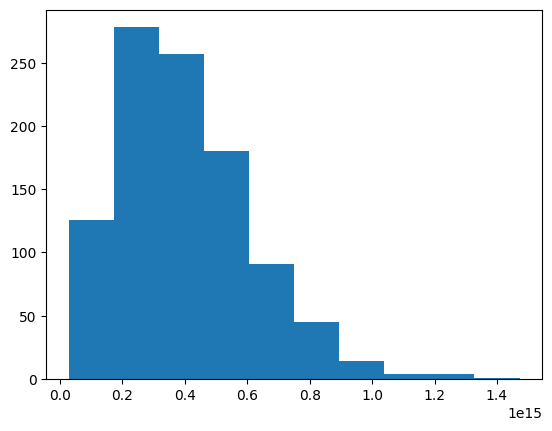

In [2]:
def sample_blackbody_frequencies(T, size=1):
    """
    Sample frequencies (Hz) from the energy-weighted Planck distribution at temperature T (K)
    using rejection sampling with a Gamma(3, θ=2) envelope.
    """
    # Physical constants
    h = 6.62607015e-34  # Planck constant (J·s)
    k = 1.380649e-23  # Boltzmann constant (J/K)

    # Dimensionless normalization constant for the target PDF: p_x(x) = A * x^3 / (e^x - 1)
    A = 15 / np.pi**4  # ensures ∫_0^∞ p_x(x) dx = 1

    # Envelope (Gamma distribution) parameters
    # Envelope PDF: g(x) = x^2 e^{-x/2} / 16, shape=3, scale=2
    # Maximum ratio M = max_x [p_x(x)/g(x)] = 240/π^4
    M = 240 / np.pi**4

    samples = []
    while len(samples) < size:
        # Draw from envelope gamma(k=3, θ=2)
        x = np.random.gamma(shape=3, scale=2)
        # Compute target and envelope densities at x
        f_target = A * x**3 / (np.exp(x) - 1)
        g = (x**2 * np.exp(-x / 2)) / 16
        # Accept-reject step
        if np.random.rand() <= f_target / (M * g):
            samples.append(x)

    # Convert dimensionless x to physical frequency ν = (kT/h) x
    x_arr = np.array(samples)
    frequencies = (k * T / h) * x_arr
    return frequencies


def mode_blackbody_frequency(T):
    """
    Return the mode of the energy-weighted Planck PDF (Hz) at temperature T (K).
    """
    h = 6.62607015e-34  # J·s
    k = 1.380649e-23  # J/K
    x_peak = 2.8214393721220787
    return (k * T / h) * x_peak


T = 5000  # Temperature Kelvin
freqs = sample_blackbody_frequencies(T, size=1000)
plt.hist(freqs)

freq_range = (min(freqs), max(freqs))
freq_width = 0.33 * (max(freqs) - min(freqs))
freq0_all = mode_blackbody_frequency(T)
lambda0 = td.constants.C_0 / freq0_all

In [3]:
t_slab = 1

# Simulation size and run time
Lx, Ly, Lz = (2, 2, t_slab + 5)
sim_size = (Lx + 5, Ly + 5, Lz)
run_time = 100 / np.average(freqs)
print(run_time)

# Grid specification
grid_spec = td.GridSpec.auto(wavelength=lambda0)

2.5039891823056456e-13


# Optimized code section

In [4]:
def get_optimized_domain_params(t_slab, Lx, Ly):
    """Calculate optimized domain parameters to reduce simulation volume"""
    # Move slab down to reduce total domain height
    slab_z_offset = -1.5  # Move slab down by 1.5 μm

    # Calculate optimized domain bounds
    slab_top = slab_z_offset + t_slab / 2
    slab_bottom = slab_z_offset - t_slab / 2

    # Tighter domain bounds (reduce padding)
    z_top = slab_top + 2.0  # 2 μm above slab (was 5)
    z_bottom = slab_bottom - 1.5  # 1.5 μm below slab

    Lz_optimized = z_top - z_bottom  # ~4.5 μm total (was 6)
    z_center = (z_top + z_bottom) / 2

    # Reduce lateral padding
    lateral_padding = 2.0  # Reduced from 5 to 2
    sim_size_optimized = (Lx + lateral_padding, Ly + lateral_padding, Lz_optimized)

    return slab_z_offset, sim_size_optimized, z_center


def get_optimized_runtime(freqs, reduction_factor=0.6):
    """Calculate optimized runtime with reduction factor"""
    return reduction_factor * 100 / np.average(freqs)


def get_optimized_grid_spec(lambda0, min_steps=16):
    """Get slightly coarser grid for cost reduction"""
    return td.GridSpec.auto(wavelength=lambda0, min_steps_per_wvl=min_steps)

In [5]:
def dipole_source_optimized(
    num_source,
    freqs,
    slab_z_offset,
    t_slab,
    Lx,
    Ly,
    distribution_type="blackbody",
    location_type="volume",
):
    """
    Optimized dipole source function with multiple distribution options

    Parameters:
    - distribution_type: 'blackbody', 'uniform', 'single_freq'
    - location_type: 'volume', 'surface', 'layers'
    """
    sources = []
    locs = []

    for i in range(num_source):
        # Frequency selection based on distribution type
        if distribution_type == "blackbody":
            f = freqs[i % len(freqs)]
        elif distribution_type == "uniform":
            f = np.random.uniform(min(freqs), max(freqs))
        elif distribution_type == "single_freq":
            f_central = np.mean(freqs)
            f = np.random.normal(f_central, 0.1 * f_central)

        pulse = td.GaussianPulse(freq0=f, fwidth=0.1 * f)

        # Location selection based on location type
        x_coord = np.random.uniform(-Lx / 2, Lx / 2)
        y_coord = np.random.uniform(-Ly / 2, Ly / 2)

        if location_type == "volume":
            # Original - dipoles throughout slab volume
            z_coord = np.random.uniform(
                slab_z_offset - t_slab / 2, slab_z_offset + t_slab / 2
            )
        elif location_type == "surface":
            # Dipoles only at top and bottom surfaces
            z_coord = np.random.choice(
                [slab_z_offset - t_slab / 2, slab_z_offset + t_slab / 2]
            )
        elif location_type == "layers":
            # Dipoles in discrete layers (3 layers)
            layer_positions = [
                slab_z_offset - t_slab / 3,
                slab_z_offset,
                slab_z_offset + t_slab / 3,
            ]
            z_coord = np.random.choice(layer_positions)

        polarizations = ["Ex", "Ey", "Ez", "Hx", "Hy", "Hz"]
        rand_pol = random.choice(polarizations)

        pt_dipole = td.PointDipole(
            center=(x_coord, y_coord, z_coord),
            source_time=pulse,
            polarization=rand_pol,
            interpolate=True,
        )
        sources.append(pt_dipole)
        locs.append((x_coord, y_coord, z_coord))

    return sources, locs


def get_optimized_source_count(original_count=1000, reduction_factor=0.5):
    """Reduce source count while maintaining accuracy"""
    return int(original_count * reduction_factor)

In [6]:
def create_optimized_structure(Lx, Ly, t_slab, slab_z_offset, n_slab=3.5):
    """Create structure with optimized positioning"""
    mat_slab = td.Medium(permittivity=n_slab**2, name="silicon")

    slab = td.Structure(
        geometry=td.Box(
            center=(0, 0, slab_z_offset),  # Moved down from (0,0,0)
            size=(Lx, Ly, t_slab),
        ),
        medium=mat_slab,
        name="slab",
    )
    return slab

In [ ]:
def create_optimized_monitors(slab_z_offset, t_slab, Lx, Ly, freq0_all, monitor_freqs):
    """Create optimized monitors with finite sizes - CORRECTED VERSION"""

    # Get domain bounds for monitor positioning
    domain_params = get_optimized_domain_params(t_slab, Lx, Ly)
    slab_z_offset_calc, sim_size_optimized, z_center = domain_params

    # Calculate safe bounds within domain with conservative margins
    safety_margin = 0.2
    domain_x_size = sim_size_optimized[0] - 2 * safety_margin
    domain_y_size = sim_size_optimized[1] - 2 * safety_margin
    domain_z_min = z_center - sim_size_optimized[2] / 2 + safety_margin
    domain_z_max = z_center + sim_size_optimized[2] / 2 - safety_margin

    monitor_field = td.FieldMonitor(
        center=(0, 0, slab_z_offset),
        size=(min(Lx, domain_x_size), min(Ly, domain_y_size), min(t_slab, 1.0)),
        freqs=[freq0_all],
        colocate=False,
        name="field",
    )

    monitor_time = td.FieldTimeMonitor(
        center=(0, 0, slab_z_offset),
        size=(domain_x_size * 0.9, domain_y_size * 0.9, 0),
        fields=["Ex"],
        interval=3,
        colocate=True,
        name="movie_monitor",
    )

    # Near-field flux monitor - positioned safely with FINITE size
    monitor_flux_near_z = slab_z_offset + t_slab / 2 + 0.02
    if monitor_flux_near_z > domain_z_max:
        monitor_flux_near_z = domain_z_max

    monitor_flux_near = td.FluxMonitor(
        center=(0, 0, monitor_flux_near_z),
        size=(domain_x_size * 0.6, domain_y_size * 0.6, 0),  # FINITE SIZE!
        freqs=monitor_freqs[::2],
        name="flux_near",
    )

    # Far-field flux monitor - positioned safely with FINITE size
    far_z = min(domain_z_max, slab_z_offset + 1.0)
    monitor_flux_far = td.FluxMonitor(
        center=(0, 0, far_z),
        size=(domain_x_size * 0.6, domain_y_size * 0.6, 0),  # FINITE SIZE!
        freqs=monitor_freqs[::2],
        name="flux_far",
    )

    return [monitor_field, monitor_time, monitor_flux_near, monitor_flux_far]

In [8]:
def create_optimized_simulation(
    T=5000, num_sources=500, distribution_type="blackbody", location_type="volume"
):
    """
    Create fully optimized simulation with all cost-reduction measures
    """
    # Get frequencies
    freqs = sample_blackbody_frequencies(T, size=1000)

    # Optimized parameters
    t_slab = 1
    Lx, Ly = (2, 2)

    slab_z_offset, sim_size_optimized, z_center = get_optimized_domain_params(
        t_slab, Lx, Ly
    )
    run_time_optimized = get_optimized_runtime(freqs)
    grid_spec_optimized = get_optimized_grid_spec(
        td.constants.C_0 / mode_blackbody_frequency(T)
    )

    # Create optimized components
    sources, locs = dipole_source_optimized(
        num_sources,
        freqs,
        slab_z_offset,
        t_slab,
        Lx,
        Ly,
        distribution_type,
        location_type,
    )

    structure = create_optimized_structure(Lx, Ly, t_slab, slab_z_offset)

    monitor_freqs = np.linspace(min(freqs), max(freqs), 100)  # Reduced from 200
    monitors = create_optimized_monitors(
        slab_z_offset, t_slab, Lx, Ly, mode_blackbody_frequency(T), monitor_freqs
    )

    # Create simulation
    sim = td.Simulation(
        center=(0, 0, z_center),  # Centered on optimized domain
        size=sim_size_optimized,
        grid_spec=grid_spec_optimized,
        structures=[structure],
        sources=sources,
        monitors=monitors,
        run_time=run_time_optimized,
        boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
        normalize_index=None,
    )

    return sim, sources, locs, freqs

In [ ]:
def validate_simulation(sim):
    """Check if simulation components are properly positioned"""
    sim_bounds = sim.simulation_bounds
    print(f"Simulation bounds: {sim_bounds}")

    # Check structures
    for i, structure in enumerate(sim.structures):
        struct_bounds = structure.geometry.bounds
        print(f"Structure {i} bounds: {struct_bounds}")

        # Check if structure is too close to PML
        for axis_idx, axis in enumerate(["x", "y", "z"]):
            struct_min = struct_bounds[0][axis_idx]
            struct_max = struct_bounds[1][axis_idx]
            sim_min = sim_bounds[0][axis_idx]
            sim_max = sim_bounds[1][axis_idx]

            # Check minimum distance to boundaries
            dist_to_min = struct_min - sim_min
            dist_to_max = sim_max - struct_max

            if dist_to_min < 0.3 or dist_to_max < 0.3:
                print(
                    f"WARNING: Structure too close to PML on {axis}-axis: "
                    f"dist_min={dist_to_min:.3f}, dist_max={dist_to_max:.3f}"
                )

    # Check monitors
    for monitor in sim.monitors:
        if hasattr(monitor, "center") and hasattr(monitor, "size"):
            mon_bounds = monitor.geometry.bounds
            print(f"Monitor '{monitor.name}' bounds: {mon_bounds}")

            # Check if monitor is outside domain
            for axis_idx in range(3):
                mon_min = mon_bounds[0][axis_idx]
                mon_max = mon_bounds[1][axis_idx]
                sim_min = sim_bounds[0][axis_idx]
                sim_max = sim_bounds[1][axis_idx]

                if mon_min < sim_min or mon_max > sim_max:
                    print(
                        f"ERROR: Monitor '{monitor.name}' outside domain on axis {axis_idx}"
                    )

    return True

In [ ]:
# Test the optimized simulation
print("=== Testing Optimized Simulation ===")

try:
    sim_optimized, sources_opt, locs_opt, freqs_opt = create_optimized_simulation()
    print("✓ Simulation created successfully")

    # Compare simulation sizes
    print(f"\nDomain comparison:")
    print(f"Original simulation size: {sim.size}")
    print(f"Optimized simulation size: {sim_optimized.size}")
    size_reduction = (
        1
        - (sim_optimized.size[0] * sim_optimized.size[1] * sim_optimized.size[2])
        / (sim.size[0] * sim.size[1] * sim.size[2])
    ) * 100
    print(f"Volume reduction: {size_reduction:.1f}%")

    # Source count comparison
    print(f"\nSource count comparison:")
    print(f"Original sources: {len(sources)}")
    print(f"Optimized sources: {len(sources_opt)}")
    print(f"Source reduction: {(1 - len(sources_opt)/len(sources))*100:.1f}%")

    # Validate simulation bounds
    print(f"\n=== Validation Results ===")
    validate_simulation(sim_optimized)

    # Try to plot
    try:
        sim_optimized.plot_3d()
        print(f"\n✓ 3D plot successful")
    except Exception as plot_error:
        print(f"\n✗ Plot failed: {plot_error}")

except Exception as e:
    print(f"✗ Simulation creation failed: {e}")
    import traceback

    traceback.print_exc()

=== Testing Optimized Simulation ===


10:36:01 BST WARNING: Structure at structures[0] was detected as being less than
             half of a central wavelength from a PML on side x-min. To avoid    
             inaccurate results or divergence, please increase gap between any  
             structures and PML or fully extend structure through the pml.      

             WARNING: Suppressed 211 WARNING messages.                          

✓ Simulation created successfully

Domain comparison:
✗ Simulation creation failed: name 'sim' is not defined


Traceback (most recent call last):
  File "/tmp/ipykernel_4046/3560179914.py", line 10, in <module>
    print(f"Original simulation size: {sim.size}")
                                       ^^^
NameError: name 'sim' is not defined. Did you mean: 'sum'?


# End of optimized code section

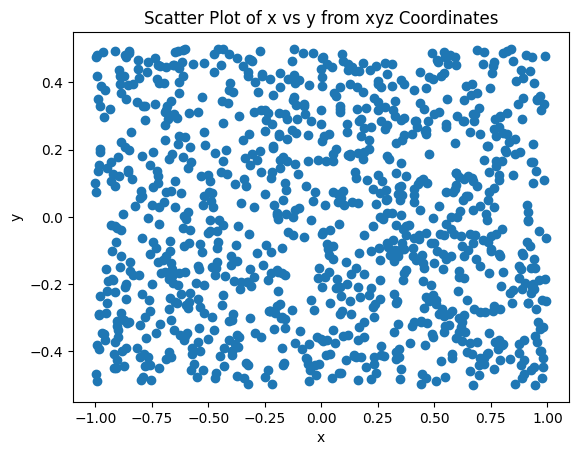

In [11]:
def dipole_source(num_source, freqs):
    sources = []
    locs = []
    for i in range(num_source):
        f = freqs[i]
        pulse = td.GaussianPulse(freq0=f, fwidth=0.1 * f)
        # Source definition
        x_coord = np.random.uniform(-Lx / 2, Lx / 2)
        y_coord = np.random.uniform(-Ly / 2, Ly / 2)
        z_coord = np.random.uniform(-t_slab / 2, t_slab / 2)
        polarizations = ["Ex", "Ey", "Ez", "Hx", "Hy", "Hz"]
        rand_pol = random.choice(polarizations)
        pt_dipole = td.PointDipole(
            center=(x_coord, y_coord, z_coord),
            source_time=pulse,
            polarization=rand_pol,
            interpolate=True,
        )
        sources.append(pt_dipole)
        locs.append((x_coord, y_coord, z_coord))
    return sources, locs


sources, locs = dipole_source(1000, freqs)

# Extract x and y values
x_vals = [c[0] for c in locs]
y_vals = [c[1] for c in locs]
z_vals = [c[2] for c in locs]

# Create scatter plot of x vs y
plt.scatter(x_vals, z_vals)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter Plot of x vs y from xyz Coordinates")
plt.show()

In [12]:
n_slab = 3.5
mat_slab = td.Medium(permittivity=n_slab**2, name="silicon")

slab = td.Structure(
    geometry=td.Box(
        center=(0, 0, 0),
        size=(Lx, Ly, t_slab),
    ),
    medium=mat_slab,
    name="slab",
)

In [13]:
monitor_field = td.FieldMonitor(
    center=(0, 0, 0),
    size=(Lx, Ly, t_slab),
    freqs=[freq0_all],
    colocate=False,
    name="field",
)

monitor_time = td.FieldTimeMonitor(
    center=(0, 0, 0),
    size=(Lx + 2, Ly + 2, 0),
    fields=["Ex"],
    interval=2,
    colocate=True,
    name="movie_monitor",
)

monitor_freqs = np.linspace(min(freqs), max(freqs), 200)
monitor_flux_near = td.FluxMonitor(
    center=(0, 0, t_slab / 2 + lambda0),
    size=(td.inf, td.inf, 0),
    freqs=monitor_freqs,
    name="flux_near",
)

monitor_flux_far = td.FluxMonitor(
    center=(0, 0, t_slab / 2 + 2),
    size=(td.inf, td.inf, 0),
    freqs=monitor_freqs,
    name="flux_far",
)

In [14]:
sim = td.Simulation(
    center=(0, 0, 0),
    size=sim_size,
    grid_spec=grid_spec,
    structures=[slab],
    sources=sources,
    monitors=[monitor_field, monitor_time, monitor_flux_near, monitor_flux_far],
    run_time=run_time,
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
    normalize_index=None,
)

             WARNING: Structure at structures[0] was detected as being less than
             half of a central wavelength from a PML on side x-min. To avoid    
             inaccurate results or divergence, please increase gap between any  
             structures and PML or fully extend structure through the pml.      

             WARNING: Suppressed 29 WARNING messages.                           

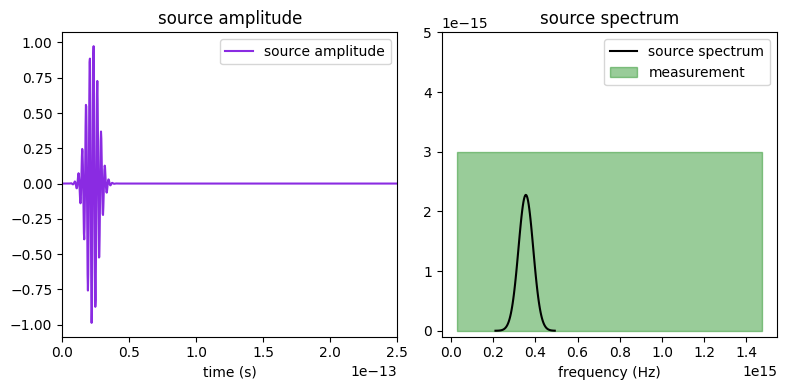

In [15]:
times = np.arange(0, sim.run_time, sim.dt)
amps = np.real(sim.sources[0].source_time.amp_time(times))
# Check probe and source
f, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(8, 4))
ax1 = sim.sources[1].source_time.plot(times=np.linspace(0, sim.run_time, 1001), ax=ax1)
ax1.set_xlim(0, sim.run_time)
ax1.legend(("source amplitude",))
ax2 = sim.sources[1].source_time.plot_spectrum(
    times=np.linspace(0, sim.run_time, 1001), val="abs", ax=ax2
)
fill_max = 30e-16  # 10e-16
ymax = 50e-16  # 20e-16
ax2.fill_between(
    freq_range, [-0e-16, -0e-16], [fill_max, fill_max], alpha=0.4, color="g"
)
ax2.legend(("source spectrum", "measurement"))
ax2.set_ylim(-1e-16, ymax)
plt.show()

In [16]:
sim_data = web.run(
    sim, task_name="rand_dipole_data", path=f"data/r_dipole_data_vac.hdf5", verbose=True
)

10:36:02 BST Created task 'rand_dipole_data' with task_id                       
             'fdve-292551bc-cf63-4a50-8c32-a84bb0580c6b' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=1977;https://tidy3d.simulation.cloud/workbench?taskId=fdve-292551bc-cf63-4a50-8c32-a84bb0580c6b\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=583575;https://tidy3d.simulation.cloud/workbench?taskId=fdve-292551bc-cf63-4a50-8c32-a84bb0580c6b\taskId]8;;\]8;id=1977;https://tidy3d.simulation.cloud/workbench?taskId=fdve-292551bc-cf63-4a50-8c32-a84bb0580c6b\=]8;;\]8;id=197525;https://tidy3d.simulation.cloud/workbench?taskId=fdve-292551bc-cf63-4a50-8c32-a84bb0580c6b\fdve]8;;\]8;id=1977;https://tidy3d.simulation.cloud/workbench?taskId=fdve-292551bc-cf63-4a50-8c32-a84bb0580c6b\-292551bc-cf6]8;;\
             ]8;id=1977;https://tidy3d.simulation.cloud/workbench?taskId=fdve-292551bc-cf63-4a50-8c32-a84bb0580c6b\3-4a50-8c32-a84bb0580c6b']8;;\.

             Task folder: ]8;id=589271;https://tidy3d.simulation.cloud/folders/folder-3acfebee-3583-4698-8828-61a1d114e4a1\'default']8;;\.

/root/tidy3D/Superblackbody/.venv/lib/python3.12/site-packages/rich/live.py:231:
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

10:36:05 BST Maximum FlexCredit cost: 0.025. Minimum cost depends on task       
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

...

10:37:19 BST loading simulation from data/r_dipole_data_vac.hdf5

             WARNING: Structure at structures[0] was detected as being less than
             half of a central wavelength from a PML on side x-min. To avoid    
             inaccurate results or divergence, please increase gap between any  
             structures and PML or fully extend structure through the pml.      

             WARNING: Suppressed 29 WARNING messages.                           

             WARNING: Simulation final field decay value of 0.461 is greater    
             than the simulation shutoff threshold of 1e-05. Consider running   
             the simulation again with a larger 'run_time' duration for more    
             accurate results.                                                  

             WARNING: Warning messages were found in the solver log. For more   
             information, check 'SimulationData.log' or use                     
             'web.download_log(task_id)'.                                       

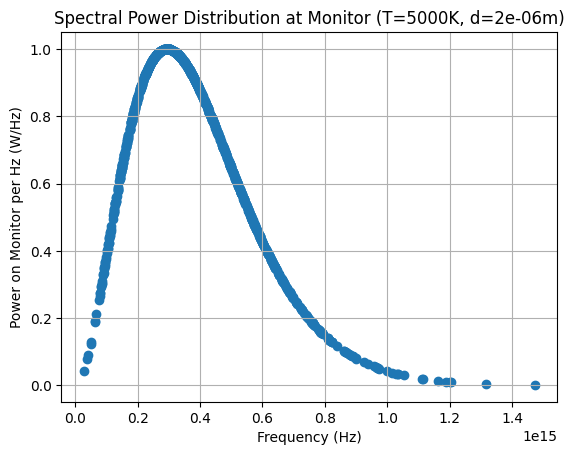

In [17]:
# === User Inputs ===
A_source = (Lx * Ly) * 10 ** (-6)

d = 2e-6  # Distance from source to monitor in meters
monitor_width = (Lx + 5) * 10 ** (-6)  # Monitor width in meters (example: 20 cm)
monitor_height = (Ly + 5) * 10 ** (-6)  # Monitor height in meters (example: 10 cm)
A_monitor = monitor_width * monitor_height  # Monitor area (m^2)

# === Physical Constants ===
h = 6.62607015e-34  # Planck constant (J·s)
c = 299792458  # Speed of light (m/s)
k_B = 1.380649e-23  # Boltzmann constant (J/K)

# === Frequency Grid ===
nu = freqs

# === Planck Law Computation ===
B_nu = (2 * h * nu**3 / c**2) / (
    np.exp(h * nu / (k_B * T)) - 1
)  # Spectral radiance (W·m⁻²·sr⁻¹·Hz⁻¹)
M_nu = np.pi * B_nu  # Spectral exitance from source (W·m⁻²·Hz⁻¹)

# === Power Emitted by Source per Hz ===
P_nu_total = M_nu * A_source  # Total power per Hz emitted into hemisphere (W/Hz)

# === Flux at Monitor per Hz ===
F_nu_monitor = P_nu_total / (4 * np.pi * d**2)  # Inverse-square law (W·m⁻²·Hz⁻¹)

# === Power Received by Monitor per Hz ===
P_nu_monitor = F_nu_monitor * A_monitor  # (W/Hz)

plt.figure()
plt.scatter(nu, P_nu_monitor / max(P_nu_monitor))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power on Monitor per Hz (W/Hz)")
plt.title(f"Spectral Power Distribution at Monitor (T={T}K, d={d}m)")
plt.grid(True)
plt.show()

Text(0.5, 1.0, 'Normalised Frequency distribution')

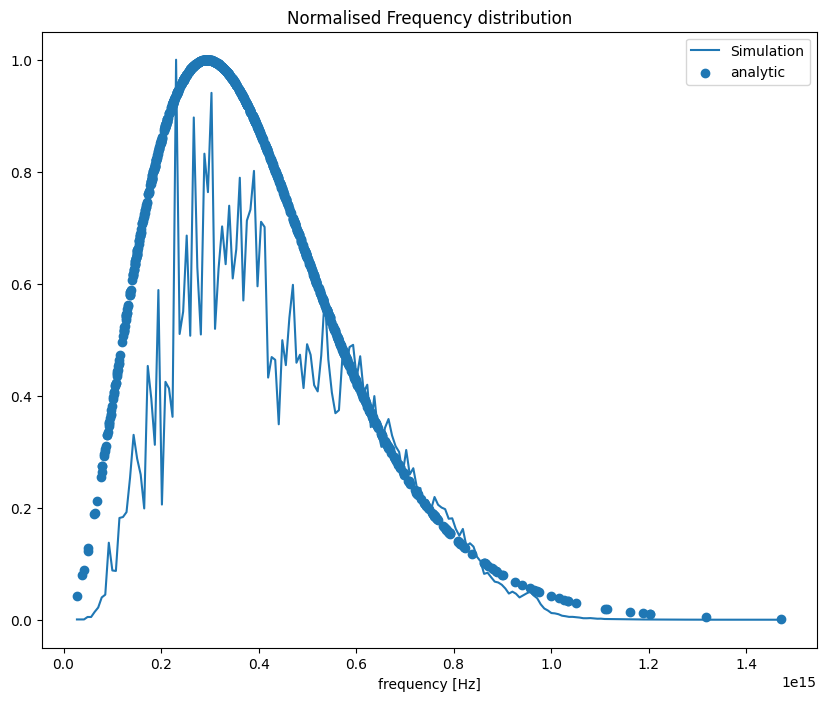

In [18]:
fig, ax1 = plt.subplots(figsize=(10, 8))
transmission_far = sim_data["flux_far"].flux
transmission_far = transmission_far / max(transmission_far)
transmission_far.plot(ax=ax1, label="Simulation")
ax1.scatter(nu, P_nu_monitor / max(P_nu_monitor), label="analytic")
ax1.legend()
ax1.set_title("Normalised Frequency distribution")

Text(0.5, 1.0, 'raw transmission')

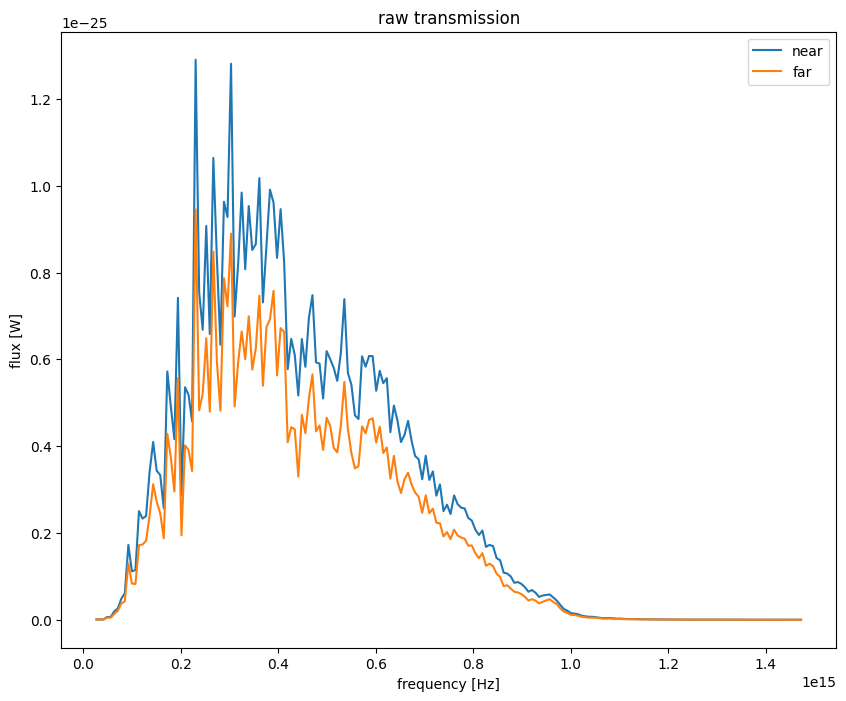

In [19]:
fig, ax1 = plt.subplots(figsize=(10, 8))
transmission_near = sim_data["flux_near"].flux
transmission_near.plot(ax=ax1, label="near")
transmission_far = sim_data["flux_far"].flux
transmission_far.plot(ax=ax1, label="far")
ax1.legend()
ax1.set_title("raw transmission")

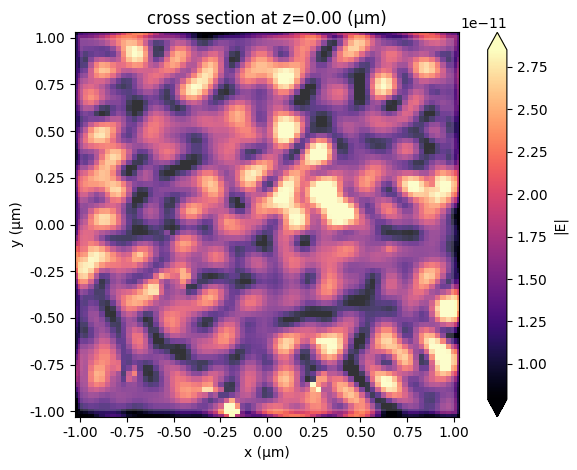

In [20]:
sim_data.plot_field(field_monitor_name="field", field_name="E", val="abs", z=0)
plt.show()

MovieWriter ffmpeg unavailable; using Pillow instead.


ValueError: unknown file extension: .mp4

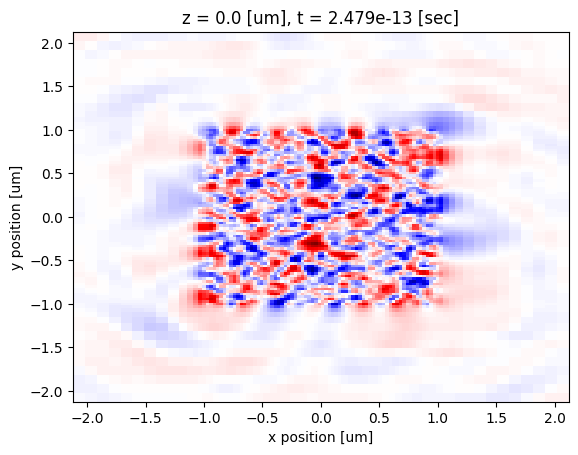

In [21]:
import matplotlib.animation as animation
from IPython.display import HTML

t_end = sim_data["movie_monitor"].Ex.coords["t"][-1]  # end time of the animation
frames = 100  # number of frames

plt.rcParams["animation.html"] = "jshtml"

fig, ax = plt.subplots()


def animate(i):
    ax.clear()
    t = t_end * i / frames
    da = sim_data["movie_monitor"].Ex.sel(t=t, method="nearest")
    im = da.plot(x="x", y="y", ax=ax, add_colorbar=False, cmap="seismic")
    return (im,)


ani = animation.FuncAnimation(fig, animate, frames=frames, blit=True, interval=100)

# 2) Save to MP4:
ani.save(
    "field_evolution.mp4",
    writer="ffmpeg",  # use 'imagemagick' if you prefer a GIF
    fps=10,  # frames per second
    dpi=200,
)  # resolution control